# CN3S Inference

In [11]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import xarray as xr

from cn3s.model import CN3S
from cn3s.params import CN3SParams
from hydro.station import Station


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:
import geopandas as gpd
import pandas as pd
from mergedownloader.downloader import Downloader
from mergedownloader.file_downloader import DownloadMode, FileDownloader
from mergedownloader.inpeparser import InpeParsers, InpeTypes
from mergedownloader.utils import GISUtil

## Configuration

In [116]:
DATA_ROOT = Path("/data/CN3S")
STATION_CODE = 29050000
FREQ = "M"
OPTIMIZATION = "ExtremeFlowBlend_alfa_livre.json"
YEAR = "2026"
START_MONTH = "09"

station_dir = DATA_ROOT / "stations" / str(STATION_CODE)
downloads_dir = DATA_ROOT / "downloads"

station = Station.from_folder(station_dir)

## Test the model calibration

In [4]:
params = CN3SParams.from_file(station_dir / f"optim/{OPTIMIZATION}")
model = CN3S(params=params, freq=FREQ)
data = station.get_optim_data(FREQ)

model.run(data["prec_mm"])
model.evaluate(data["q_m3s"])
model.plot()

Running CN3S model:   0%|          | 0/317 [00:00<?, ?step/s]

Aligned 297 time steps between model results and observations.
From 2000-05-01 00:00:00 to 2026-09-01 00:00:00.


## Load N-month forecast

In [10]:
MODELS = {
    "UKMO GloaSea6-GC5.1": {"originating_centre": "ukmo", "system": "610"},
    "ECMWF SEAS5": {"originating_centre": "ecmwf", "system": "51"},
    "Meteo France S9": {"originating_centre": "meteo_france", "system": "9"},
    "DWD GCFS2.2": {"originating_centre": "dwd", "system": "22"},
    "CMCC SPS4": {"originating_centre": "cmcc", "system": "4"},
    "NCEP CFSv2": {"originating_centre": "ncep", "system": "2"},
    "JMA CPS4": {"originating_centre": "jma", "system": "4"},
    "ECCC GEM5.2-NEMO": {"originating_centre": "eccc", "system": "5"},
    "BOM ACCESS-S2": {"originating_centre": "bom", "system": "2"},
}

In [121]:
forecast = {}

forecast_data = {
    "prec": "tprate",
    "anomaly": "tpara",
    "hindcast": "tprate",
}

# Loop through each variable and process the corresponding forecast data
for variable, varname in forecast_data.items():
    tmp_list = []

    # Here, we loop through each model. Each name will be used as the coordinate for the "model" dimension
    for i, model_name in enumerate(MODELS):
        prec_file = MODELS[model_name]["originating_centre"] + f"_{YEAR}{START_MONTH}.nc2"
        ds = xr.open_dataset(DATA_ROOT / "forecasts" / variable / prec_file)

        arr = ds[varname].rename(MODELS[model_name]["originating_centre"])

        # Assume the first model as the base model for shape size
        if i == 0:
            ref_latitude = ds.latitude
            ref_longitude = ds.longitude
        else:
            arr = arr.interp(latitude=ref_latitude, longitude=ref_longitude)

        tmp_list.append(arr)

    # Once our list is populated with all models, we can combine them along the "model" dimension
    model_names = [array.name for array in tmp_list]
    combined = xr.concat(
        tmp_list,
        dim=xr.IndexVariable("model", model_names),
    ).rename(variable)

    combined = combined.rio.write_crs("EPSG:4326")

    # Store the combined dataset in the forecast dictionary
    forecast[variable] = GISUtil.cut_cube_by_geoms(combined, station.upstream_watershed.geometry)

forecast["prec"].shape

(9, 5, 12, 9)

## Load Average Precipitation

In [37]:
downloader = Downloader(
    file_downloader=FileDownloader(download_mode=DownloadMode.NO_UPDATE),
    local_folder="/data/CN3S/downloads",
    parsers=InpeParsers,
)

Using HTTP downloads


In [71]:
# Get the observed rain. We will use until the current day to force it accumulate the current month.
today = pd.Timestamp.now()
obs_range = pd.date_range(
    start=today - pd.DateOffset(months=13),
    end=today,
    freq="MS",
    normalize=True,
)

prec_obs = downloader.create_cube(
    obs_range[0].to_pydatetime(),
    obs_range[-1].to_pydatetime(),
    InpeTypes.MONTHLY_ACCUM_MANUAL,
)

prec_obs = GISUtil.cut_cube_by_geoms(prec_obs, station.upstream_watershed.geometry)

prec_obs = prec_obs.mean(dim=["latitude", "longitude"])


In [78]:
# Get the average rain. We have to cover the same start date as the observed rain.
# but the last date can be the last date considered in the forecasts
steps = len(forecast["prec"].step)
fcst_start = pd.Timestamp(YEAR + "-" + START_MONTH)
end = fcst_start + pd.DateOffset(months=steps - 1)
avg_range = pd.date_range(
    start=today - pd.DateOffset(months=13),
    end=end,
    freq="MS",
    normalize=True,
)
prec_avg = downloader.create_cube(
    avg_range[0].to_pydatetime(),
    avg_range[-1].to_pydatetime(),
    InpeTypes.MONTHLY_ACCUM,
)

prec_avg = GISUtil.cut_cube_by_geoms(prec_avg, station.upstream_watershed.geometry)
prec_avg = prec_avg.mean(dim=["latitude", "longitude"])

# THe MONTHLY_ACCUM comes with past dates, so we need to set the time coordinate explicitly
prec_avg["time"] = avg_range


In [122]:
steps = len(forecast["prec"].step)

if today.month > fcst_start.month:
    steps -= 1

for variable, arr in forecast.items():
    forecast[variable] = arr.isel(step=slice(-steps, None))
    forecast[variable]["step"] = avg_range[-steps:]


In [101]:
prec_fcst = forecast["prec"].mean(dim=["latitude", "longitude", "model"])

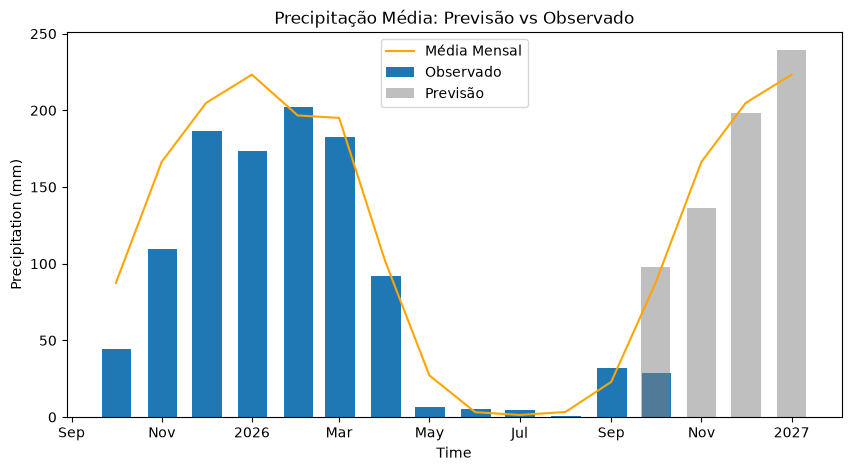

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
prec_avg.plot(ax=ax, label="Média Mensal", color="orange")
ax.bar(prec_obs["time"], prec_obs, width=20.0, label="Observado")

ax.bar(prec_fcst["step"], prec_fcst, width=20.0, label="Previsão", alpha=0.5, color="grey")


ax.set_title("Precipitação Média: Previsão vs Observado")
ax.set_xlabel("Time")
ax.set_ylabel("Precipitation (mm)")

ax.legend()

## Adjust Forecast Rain BIAS

The idea here is to use the forecast models to calculate the anomaly in percentage. This percentage anomaly will then be applied to the observed climatology. 



In [123]:
forecast["perc_anomaly"] = forecast["prec"] / forecast["hindcast"]

In [127]:
fcst_anomaly_perc = 100 * (forecast["perc_anomaly"].mean(dim=["longitude", "latitude"]) - 1)

In [129]:
import plotly.express as px

df = fcst_anomaly_perc.to_dataframe(name="Anomaly (%)").reset_index()
df["Month"] = df["step"].dt.strftime("%b %Y")

fig = px.bar(
    df,
    x="Month",
    y="Anomaly (%)",
    color="model",
    barmode="group",
    title="Monthly precipitation anomaly by forecast model",
    labels={"model": "Forecast model"},
)

fig.update_layout(
    yaxis_title="Precipitation anomaly (%)",
    xaxis_title="",
    legend_title="Model",
    template="plotly_white",
    hovermode="x unified",
)

fig.add_hline(y=0, line_color="black", line_width=1)

fig.show()

In [223]:
import pandas as pd
import plotly.graph_objects as go

# Calculate corrected precipitation
avg_fcst = prec_avg.sel(time=fcst_anomaly_perc.step)
prec_corrected = avg_fcst * (1 + fcst_anomaly_perc / 100)

# Convert dates to timestamps
fcst_dates = pd.to_datetime(prec_corrected.step.values)

# Widths in milliseconds
DAY = 24 * 60 * 60 * 1000
BAR_WIDTH = 20 * DAY
BOX_WIDTH = 12 * DAY

fig = go.Figure()

# 1. Historical climatology
fig.add_trace(
    go.Scatter(
        x=prec_avg.time.values,
        y=prec_avg.values,
        mode="lines",
        name="Média mensal",
        line={"color": "darkorange", "width": 3},
    )
)


# 2. Corrected forecast (median)
fig.add_trace(
    go.Bar(
        x=fcst_dates,
        y=prec_corrected.median(dim="model").values,
        name="Previsão (mediana)",
        marker_color="lightgray",
        width=BAR_WIDTH,
    )
)


# 3. Observed precipitation
fig.add_trace(
    go.Bar(
        x=prec_obs.time.values,
        y=prec_obs.values,
        name="Observado",
        marker_color="steelblue",
        width=BAR_WIDTH,
    )
)
# 4. Boxplots showing model distribution
for i, step in enumerate(prec_corrected.step.values):
    values = prec_corrected.sel(step=step).values
    date = fcst_dates[i]

    fig.add_trace(
        go.Box(
            x=[date] * len(values),
            y=values,
            name="Distribuição dos modelos",
            width=BOX_WIDTH,
            marker={
                "color": "dimgray",
                "size": 5,
                "opacity": 0.8,
            },
            line={"color": "black", "width": 1.5},
            fillcolor="rgba(100,100,100,0.25)",
            boxpoints="all",
            jitter=0.0,
            pointpos=0,
            showlegend=(i == 0),
            hovertemplate="%{y:.1f} mm<extra></extra>",
        )
    )

title = f"{station.name} ({station.code}) - "
title += "Precipitação mensal: observações e previsão corrigida"
fig.update_layout(
    title=title,
    xaxis_title="",
    yaxis_title="Precipitação (mm)",
    template="plotly_white",
    hovermode="closest",
    # Crucial: overlap instead of grouping
    barmode="overlay",
    boxmode="overlay",
    legend={
        "orientation": "h",
        "y": 1.12,
        "x": 0,
    },
    height=550,
    bargap=0.25,
)

fig.update_yaxes(
    rangemode="tozero",
    showgrid=True,
    gridcolor="rgba(0,0,0,0.08)",
)

fig.show()

AttributeError: 'DataFrame' object has no attribute 'sel'

## Run model with prediction

Now, we have to add the predicted rain to run the model again
We will run the model for 2 distinct situations. If rains the average and if it rains the predicted.

In [157]:
# first, let's create separate columns for forecasted and average precipitation
data["prec_fcst"] = data["prec_mm"]
data["prec_avg"] = data["prec_mm"]

# Then, let's add the values

In [186]:
data.tail()

,prec_mm,q_m3s,prec_fcst,prec_avg
date,,,,
2026-05-01,6.500626,10529.482816,6.500626,6.500626
2026-06-01,4.328246,5197.531222,4.328246,4.328246
2026-07-01,4.803958,3315.959915,4.803958,4.803958
2026-08-01,0.736519,2022.291857,0.736519,0.736519
2026-09-01,33.027168,1364.446962,33.027168,33.027168


In [173]:
prec_fcst = prec_corrected.median(dim="model").to_dataframe(name="prec_fcst").drop(columns=["time", "spatial_ref"])
prec_fcst.index.name = "date"
prec_fcst

,prec_fcst
date,
2026-10-01,85.775435
2026-11-01,128.751833
2026-12-01,176.027218
2027-01-01,196.445255


In [177]:
prec_avg = prec_avg.sel(time=prec_corrected.time)
prec_avg = prec_avg.to_dataframe(name="prec_avg").drop(columns=["time", "spatial_ref"])
prec_avg.index.name = "date"
prec_avg

,prec_avg
date,
2026-10-01,87.503646
2026-11-01,166.414089
2026-12-01,204.830448
2027-01-01,223.277350


In [188]:
data = data.combine_first(prec_fcst).combine_first(prec_avg)

In [211]:
model.run(data["prec_avg"])
fcst_avg_prec = model.results["q_m3s"]
fcst_avg_prec.index = fcst_avg_prec.index + pd.DateOffset(days=14)
fcst_avg_prec

Running CN3S model:   0%|          | 0/321 [00:00<?, ?step/s]

date
2000-05-15    15066.295096
2000-06-15     7905.438128
2000-07-15     5711.369683
2000-08-15     4176.640028
2000-09-15     3146.775563
                  ...     
2026-10-15     2166.059214
2026-11-15     3102.603046
2026-12-15     5922.216512
2027-01-15    10832.916134
2027-02-15    16989.863302
Name: q_m3s, Length: 322, dtype: object

In [212]:
model.run(data["prec_fcst"])
fcst_fcst_prec = model.results["q_m3s"]
fcst_fcst_prec.index = fcst_fcst_prec.index + pd.DateOffset(days=14)
fcst_fcst_prec

Running CN3S model:   0%|          | 0/321 [00:00<?, ?step/s]

date
2000-05-15    15066.295096
2000-06-15     7905.438128
2000-07-15     5711.369683
2000-08-15     4176.640028
2000-09-15     3146.775563
                  ...     
2026-10-15     2166.059214
2026-11-15     3070.977605
2026-12-15      4828.69802
2027-01-15     8396.295158
2027-02-15    12820.990062
Name: q_m3s, Length: 322, dtype: object

## Plot last chart

In [198]:
from utils.sql_connector import SqlConnector

conn = SqlConnector()

To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code FG3HRDPQ2 to authenticate.


In [199]:
station = Station.from_folder(station.station_dir, connector=conn)

In [200]:
station.load_series()

In [201]:
qd = station.get_series("hidro/telemetria", "vazao")


In [222]:
import plotly.graph_objects as go

stats = pd.DataFrame(
    {
        "median": qd.groupby([qd.index.month, qd.index.day])["val"].median(),
        "min": qd.groupby([qd.index.month, qd.index.day])["val"].min(),
        "max": qd.groupby([qd.index.month, qd.index.day])["val"].max(),
    },
)

stats = stats.drop((2, 29))
stats.index = pd.date_range(start="2026-01-01", end="2026-12-31")

s2025 = qd.loc["2025"]
s2026 = qd.loc["2026"]
s2024 = qd.loc["2024"]

monthly_mean = qd.groupby(qd.index.month)["val"].median()

fig = go.Figure()
fig.add_scatter(x=stats.index, y=stats["median"], mode="lines", name="Median", opacity=0.1, line={"color": "blue", "dash": "dash"})
fig.add_scatter(x=stats.index, y=stats["min"], mode="lines", name="Min", opacity=0.1, line={"color": "grey", "width": 0})
fig.add_scatter(x=stats.index, y=stats["max"], mode="lines", name="Max", opacity=0.01, line={"color": "grey", "width": 0}, fill="tonexty", fillcolor="rgba(128, 128, 128, 0.10)")
fig.add_scatter(x=stats.index, y=s2025["val"], mode="lines", name="2025", line={"color": "blue", "width": 1})
fig.add_scatter(x=stats.index, y=s2026["val"], mode="lines", name="2026", line={"color": "black"})
fig.add_scatter(x=stats.index, y=s2024["val"], mode="lines", name="2024", line={"color": "green", "width": 1})

monthly_mean = qd.groupby(qd.index.month)["val"].median()
monthly_mean = pd.Series(monthly_mean.values, index=pd.date_range("2026-01-01", freq="MS", periods=12))
monthly_mean.index = monthly_mean.index + pd.DateOffset(days=14)

monthly_line_x = []
monthly_line_y = []
for month_start, month_end, monthly_value in zip(
    month_edges[:-1], month_edges[1:], month_values
):
    monthly_line_x.extend([month_start, month_end, None])
    monthly_line_y.extend([monthly_value, monthly_value, None])


fig.add_scatter(
    x=monthly_mean.index,
    y=monthly_mean.values,
    mode="markers",
    name="Média Mensal",
    marker={"color": "orange", "size": 6, "symbol": "circle"},
)

fig.add_scatter(
    x=fcst_avg_prec.iloc[-(steps+model.params.act):].index,
    y=fcst_avg_prec.iloc[-(steps+model.params.act):].values,
    mode="markers",
    name="Previsão (chuva média)",
    marker={"color": "green", "size": 10, "symbol": "cross"},
)

fig.add_scatter(
    x=fcst_fcst_prec.iloc[-(steps+model.params.act):].index,
    y=fcst_fcst_prec.iloc[-(steps+model.params.act):].values,
    mode="markers",
    name="Previsão (chuva prevista)",
    marker={"color": "red", "size": 10, "symbol": "x"},
)

fig.add_scatter(
    x=monthly_line_x,
    y=monthly_line_y,
    mode="lines",
    name="Monthly mean",
    line={"color": "orange", "width": 1, "dash": "dot"},
)

# ...existing code...
fig.update_layout(
    width=1200,
    height=600,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis={"showline": True, "linecolor": "black", "mirror": True},
    yaxis={"showline": True, "linecolor": "black", "mirror": True, "type": "linear"},
)
fig.show()

In [224]:
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------
# 1. Historical daily climatology (P10, median, P90)
# -------------------------------------------------------

grouped = qd.groupby([qd.index.month, qd.index.day])["val"]

stats = pd.DataFrame({
    "median": grouped.median(),
    "p10": grouped.quantile(0.10),
    "p90": grouped.quantile(0.90),
})

# Extend climatology through the last forecast month
last_forecast = max(fcst_avg_prec.index.max(), fcst_fcst_prec.index.max())

dates = pd.date_range(
    "2026-01-01",
    last_forecast + pd.DateOffset(days=15),
    freq="D",
)

calendar_days = pd.MultiIndex.from_arrays([dates.month, dates.day])

stats = stats.reindex(calendar_days)
stats.index = dates

# -------------------------------------------------------
# 2. Historical years aligned to the 2026 calendar
# -------------------------------------------------------

fig = go.Figure()

# P10–P90 shaded envelope
fig.add_scatter(
    x=stats.index,
    y=stats["p10"],
    mode="lines",
    line={"width": 0},
    showlegend=False,
    hoverinfo="skip",
)

fig.add_scatter(
    x=stats.index,
    y=stats["p90"],
    mode="lines",
    name="P10–P90 histórico",
    line={"width": 0},
    fill="tonexty",
    fillcolor="rgba(128,128,128,0.15)",
    hoverinfo="skip",
)

# Historical daily median
fig.add_scatter(
    x=stats.index,
    y=stats["median"],
    mode="lines",
    name="Mediana histórica",
    line={"color": "royalblue", "dash": "dash", "width": 1},
    opacity=0.35,
)

# Individual years
for year, color, width in [
    (2024, "green", 1),
    (2025, "blue", 1),
    (2026, "black", 2),
]:
    s = qd.loc[str(year), "val"].copy()

    # Align month/day to 2026 and remove Feb 29
    s = s[~((s.index.month == 2) & (s.index.day == 29))]
    s.index = pd.to_datetime(
        [f"2026-{d.month:02d}-{d.day:02d}" for d in s.index]
    )

    fig.add_scatter(
        x=s.index,
        y=s.values,
        mode="lines",
        name=str(year),
        line={"color": color, "width": width},
    )

# -------------------------------------------------------
# 3. Historical monthly median (extended into 2027)
# -------------------------------------------------------

monthly_median = qd.groupby(qd.index.month)["val"].median()

monthly_line_x = []
monthly_line_y = []
monthly_marker_x = []
monthly_marker_y = []

month_starts = pd.date_range(
    dates.min().replace(day=1),
    dates.max() + pd.offsets.MonthBegin(1),
    freq="MS",
)

for start, end in zip(month_starts[:-1], month_starts[1:]):
    value = monthly_median.loc[start.month]

    # Horizontal segment for each month
    monthly_line_x.extend([start, end, None])
    monthly_line_y.extend([value, value, None])

    # Marker at the middle of each month
    monthly_marker_x.append(start + (end - start) / 2)
    monthly_marker_y.append(value)

fig.add_scatter(
    x=monthly_line_x,
    y=monthly_line_y,
    mode="lines",
    name="Mediana mensal",
    line={"color": "orange", "width": 1, "dash": "dot"},
)

fig.add_scatter(
    x=monthly_marker_x,
    y=monthly_marker_y,
    mode="markers",
    name="Mediana mensal (pontos)",
    marker={"color": "orange", "size": 6},
    showlegend=False,
)

# -------------------------------------------------------
# 4. Hydrological forecasts
# -------------------------------------------------------

n = steps + model.params.act

fig.add_scatter(
    x=fcst_avg_prec.iloc[-n:].index,
    y=fcst_avg_prec.iloc[-n:].values,
    mode="markers",
    name="Previsão (chuva média)",
    marker={"color": "green", "size": 10, "symbol": "cross"},
)

fig.add_scatter(
    x=fcst_fcst_prec.iloc[-n:].index,
    y=fcst_fcst_prec.iloc[-n:].values,
    mode="markers",
    name="Previsão (chuva prevista)",
    marker={"color": "red", "size": 10, "symbol": "x"},
)

# -------------------------------------------------------
# 5. Layout
# -------------------------------------------------------

fig.update_layout(
    title="Vazão observada e prevista — comparação com climatologia histórica",
    width=1200,
    height=600,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis={
        "title": "",
        "showline": True,
        "linecolor": "black",
        "mirror": True,
        "range": [dates.min(), dates.max()],
    },
    yaxis={
        "title": "Vazão (m³/s)",
        "showline": True,
        "linecolor": "black",
        "mirror": True,
        "type": "linear",
        "rangemode": "tozero",
    },
    legend={
        "orientation": "v",
        "x": 1.02,
        "y": 1,
    },
)

fig.show()

In [225]:
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------
# 1. Historical daily climatology (P10, median, P90)
# -------------------------------------------------------

grouped = qd.groupby([qd.index.month, qd.index.day])["val"]

stats = pd.DataFrame({
    "median": grouped.median(),
    "p10": grouped.quantile(0.10),
    "p90": grouped.quantile(0.90),
})

# Remove leap day and use a fixed January–December calendar
stats = stats.drop((2, 29), errors="ignore")
stats.index = pd.date_range("2026-01-01", "2026-12-31")

# -------------------------------------------------------
# 2. Historical statistics and individual years
# -------------------------------------------------------

fig = go.Figure()

# P10–P90 envelope
fig.add_scatter(
    x=stats.index,
    y=stats["p10"],
    mode="lines",
    line={"width": 0},
    showlegend=False,
    hoverinfo="skip",
)

fig.add_scatter(
    x=stats.index,
    y=stats["p90"],
    mode="lines",
    name="P10–P90 histórico",
    line={"width": 0},
    fill="tonexty",
    fillcolor="rgba(128,128,128,0.15)",
    hoverinfo="skip",
)

# Historical median
fig.add_scatter(
    x=stats.index,
    y=stats["median"],
    mode="lines",
    name="Mediana histórica",
    line={"color": "royalblue", "dash": "dash", "width": 1},
    opacity=0.35,
)

# Individual years aligned to the same calendar
for year, color, width in [
    (2024, "green", 1),
    (2025, "blue", 1),
    (2026, "black", 2),
]:
    s = qd.loc[str(year), "val"].copy()

    s = s[~((s.index.month == 2) & (s.index.day == 29))]
    s.index = pd.to_datetime(
        [f"2026-{d.month:02d}-{d.day:02d}" for d in s.index]
    )

    fig.add_scatter(
        x=s.index,
        y=s.values,
        mode="lines",
        name=str(year),
        line={"color": color, "width": width},
    )

# -------------------------------------------------------
# 3. Historical monthly median
# -------------------------------------------------------

monthly_median = qd.groupby(qd.index.month)["val"].median()

month_starts = pd.date_range("2026-01-01", "2027-01-01", freq="MS")

monthly_line_x = []
monthly_line_y = []
monthly_marker_x = []
monthly_marker_y = []

for start, end in zip(month_starts[:-1], month_starts[1:]):
    value = monthly_median.loc[start.month]

    monthly_line_x.extend([start, end, None])
    monthly_line_y.extend([value, value, None])

    monthly_marker_x.append(start + (end - start) / 2)
    monthly_marker_y.append(value)

fig.add_scatter(
    x=monthly_line_x,
    y=monthly_line_y,
    mode="lines",
    name="Mediana mensal",
    line={"color": "orange", "width": 1, "dash": "dot"},
)

fig.add_scatter(
    x=monthly_marker_x,
    y=monthly_marker_y,
    mode="markers",
    marker={"color": "orange", "size": 6},
    showlegend=False,
)

# -------------------------------------------------------
# 4. Hydrological forecasts (projected onto Jan–Dec)
# -------------------------------------------------------

n = steps + model.params.act

for series, name, color, symbol in [
    (fcst_avg_prec, "Previsão (chuva média)", "green", "cross"),
    (fcst_fcst_prec, "Previsão (chuva prevista)", "red", "x"),
]:
    forecast = series.iloc[-n:]

    # Project forecast dates onto the 2026 calendar
    plot_dates = pd.to_datetime([
        f"2026-{d.month:02d}-{d.day:02d}"
        for d in forecast.index
    ])

    fig.add_scatter(
        x=plot_dates,
        y=forecast.values,
        mode="markers",
        name=name,
        marker={"color": color, "size": 10, "symbol": symbol},
        customdata=forecast.index.strftime("%b %Y"),
        hovertemplate=(
            "%{customdata}<br>"
            "Vazão: %{y:,.0f} m³/s"
            "<extra></extra>"
        ),
    )

# -------------------------------------------------------
# 5. Layout
# -------------------------------------------------------

fig.update_layout(
    title="Vazão observada e prevista — climatologia anual",
    width=1200,
    height=600,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis={
        "title": "",
        "showline": True,
        "linecolor": "black",
        "mirror": True,
        "range": ["2026-01-01", "2026-12-31"],
        "tickformat": "%b",
        "dtick": "M1",
    },
    yaxis={
        "title": "Vazão (m³/s)",
        "showline": True,
        "linecolor": "black",
        "mirror": True,
        "type": "linear",
        "rangemode": "tozero",
    },
    legend={
        "orientation": "v",
        "x": 1.02,
        "y": 1,
    },
)

fig.show()

In [227]:
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------
# 1. Rolling 12-month window
# -------------------------------------------------------

n = steps + model.params.act

last_forecast = max(
    fcst_avg_prec.index.max(),
    fcst_fcst_prec.index.max(),
)

end_month = pd.Timestamp(last_forecast).replace(day=1)
start_date = end_month - pd.DateOffset(months=11)
end_date = end_month + pd.offsets.MonthEnd(1)

dates = pd.date_range(start_date, end_date, freq="D")

# -------------------------------------------------------
# 2. Historical daily climatology
# -------------------------------------------------------

grouped = qd.groupby([qd.index.month, qd.index.day])["val"]

stats = pd.DataFrame({
    "median": grouped.median(),
    "p10": grouped.quantile(0.10),
    "p90": grouped.quantile(0.90),
})

# Align historical calendar days to the rolling window
calendar_days = pd.MultiIndex.from_arrays([dates.month, dates.day])

stats = stats.reindex(calendar_days)
stats.index = dates

# -------------------------------------------------------
# 3. Historical statistics
# -------------------------------------------------------

fig = go.Figure()

# P10–P90 envelope
fig.add_scatter(
    x=stats.index,
    y=stats["p10"],
    mode="lines",
    line={"width": 0},
    showlegend=False,
    hoverinfo="skip",
)

fig.add_scatter(
    x=stats.index,
    y=stats["p90"],
    mode="lines",
    name="P10–P90 histórico",
    line={"width": 0},
    fill="tonexty",
    fillcolor="rgba(128,128,128,0.15)",
    hoverinfo="skip",
)

# Historical daily median
fig.add_scatter(
    x=stats.index,
    y=stats["median"],
    mode="lines",
    name="Mediana histórica",
    line={"color": "royalblue", "dash": "dash", "width": 1},
    opacity=0.35,
)

# -------------------------------------------------------
# 4. Historical years (2024 and 2025)
# -------------------------------------------------------

for year, color in [(2024, "green"), (2025, "blue")]:
    s = qd.loc[str(year), "val"].copy()

    # Shift historical dates into rolling window
    mapped_dates = pd.to_datetime([
        f"{start_date.year if d.month >= start_date.month else end_date.year}"
        f"-{d.month:02d}-{d.day:02d}"
        for d in s.index
    ], errors="coerce")

    s.index = mapped_dates

    # Remove invalid dates (e.g. Feb 29) and sort chronologically
    s = s[s.index.notna()].sort_index()

    fig.add_scatter(
        x=s.index,
        y=s.values,
        mode="lines",
        name=str(year),
        line={"color": color, "width": 1},
    )

# -------------------------------------------------------
# 5. Current year observations (actual dates)
# -------------------------------------------------------

current_year = start_date.year

s_current = qd.loc[str(current_year), "val"]

fig.add_scatter(
    x=s_current.index,
    y=s_current.values,
    mode="lines",
    name=str(current_year),
    line={"color": "black", "width": 2},
)

# -------------------------------------------------------
# 6. Historical monthly median
# -------------------------------------------------------

monthly_median = qd.groupby(qd.index.month)["val"].median()

month_starts = pd.date_range(
    start_date,
    end_month + pd.DateOffset(months=1),
    freq="MS",
)

monthly_line_x = []
monthly_line_y = []
monthly_marker_x = []
monthly_marker_y = []

for start, end in zip(month_starts[:-1], month_starts[1:]):
    value = monthly_median.loc[start.month]

    monthly_line_x.extend([start, end, None])
    monthly_line_y.extend([value, value, None])

    monthly_marker_x.append(start + (end - start) / 2)
    monthly_marker_y.append(value)

fig.add_scatter(
    x=monthly_line_x,
    y=monthly_line_y,
    mode="lines",
    name="Mediana mensal",
    line={"color": "orange", "width": 1, "dash": "dot"},
)

fig.add_scatter(
    x=monthly_marker_x,
    y=monthly_marker_y,
    mode="markers",
    marker={"color": "orange", "size": 6},
    showlegend=False,
)

# -------------------------------------------------------
# 7. Hydrological forecasts (actual dates)
# -------------------------------------------------------

fig.add_scatter(
    x=fcst_avg_prec.iloc[-n:].index,
    y=fcst_avg_prec.iloc[-n:].values,
    mode="markers",
    name="Previsão (chuva média)",
    marker={"color": "green", "size": 10, "symbol": "cross"},
)

fig.add_scatter(
    x=fcst_fcst_prec.iloc[-n:].index,
    y=fcst_fcst_prec.iloc[-n:].values,
    mode="markers",
    name="Previsão (chuva prevista)",
    marker={"color": "red", "size": 10, "symbol": "x"},
)

# -------------------------------------------------------
# 8. Layout
# -------------------------------------------------------

fig.update_layout(
    title="Vazão observada e prevista — janela móvel de 12 meses",
    width=1200,
    height=600,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis={
        "title": "",
        "showline": True,
        "linecolor": "black",
        "mirror": True,
        "range": [start_date, end_date],
        "tickformat": "%b %Y",
        "dtick": "M1",
    },
    yaxis={
        "title": "Vazão (m³/s)",
        "showline": True,
        "linecolor": "black",
        "mirror": True,
        "rangemode": "tozero",
    },
    legend={
        "orientation": "v",
        "x": 1.02,
        "y": 1,
    },
)

fig.show()

In [233]:
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------
# 1. Rolling 12-month window
# -------------------------------------------------------

n = steps + model.params.act

last_forecast = max(
    fcst_avg_prec.index.max(),
    fcst_fcst_prec.index.max(),
)

end_month = pd.Timestamp(last_forecast).replace(day=1)
start_date = end_month - pd.DateOffset(months=11)

# Exclusive right boundary: first day of the next month
end_date = end_month + pd.DateOffset(months=1)

dates = pd.date_range(
    start_date,
    end_date - pd.Timedelta(days=1),
    freq="D",
)

# Current month
current_month = pd.Timestamp.today()#.to_period("M").to_timestamp()

# -------------------------------------------------------
# 2. Historical daily climatology
# -------------------------------------------------------

grouped = qd.groupby([qd.index.month, qd.index.day])["val"]

stats = pd.DataFrame({
    "median": grouped.median(),
    "p10": grouped.quantile(0.10),
    "p90": grouped.quantile(0.90),
})

calendar_days = pd.MultiIndex.from_arrays(
    [dates.month, dates.day]
)

stats = stats.reindex(calendar_days)
stats.index = dates

# -------------------------------------------------------
# 3. Historical percentile envelope and median
# -------------------------------------------------------

fig = go.Figure()

fig.add_scatter(
    x=stats.index,
    y=stats["p10"],
    mode="lines",
    line={"width": 0},
    showlegend=False,
    hoverinfo="skip",
)

fig.add_scatter(
    x=stats.index,
    y=stats["p90"],
    mode="lines",
    name="P10–P90 histórico",
    line={"width": 0},
    fill="tonexty",
    fillcolor="rgba(128,128,128,0.15)",
    hoverinfo="skip",
)

fig.add_scatter(
    x=stats.index,
    y=stats["median"],
    mode="lines",
    name="Mediana histórica",
    line={
        "color": "royalblue",
        "dash": "dash",
        "width": 1,
    },
    opacity=0.35,
)

# -------------------------------------------------------
# 4. Historical years projected onto rolling window
# -------------------------------------------------------

colors = {
    2024: "green",
    2025: "blue",
    2026: "black",
}

split_month = start_date.month

for year, color in colors.items():

    s = qd.loc[str(year), "val"].copy()

    # Remove leap day
    s = s[~((s.index.month == 2) & (s.index.day == 29))]

    segments = [
        s[s.index.month >= split_month],
        s[s.index.month < split_month],
    ]

    for segment_idx, segment in enumerate(segments):

        if segment.empty:
            continue

        target_year = (
            start_date.year if segment_idx == 0
            else end_date.year
        )

        mapped_dates = pd.to_datetime([
            f"{target_year}-{d.month:02d}-{d.day:02d}"
            for d in segment.index
        ])

        fig.add_scatter(
            x=mapped_dates,
            y=segment.values,
            mode="lines",
            name=str(year),
            legendgroup=str(year),
            showlegend=(segment_idx == 0),
            line={
                "color": color,
                "width": 2 if year == 2026 else 1,
            },
        )

# -------------------------------------------------------
# 5. Connect December to January of following year
# -------------------------------------------------------

# Only needed when the rolling window crosses Dec-Jan
year_boundary = pd.Timestamp(
    year=start_date.year + 1,
    month=1,
    day=1,
)

if start_date < year_boundary < end_date:

    for year in [2024, 2025]:

        dec = qd.loc[f"{year}-12", "val"]
        jan = qd.loc[f"{year + 1}-01", "val"]

        if dec.empty or jan.empty:
            continue

        dec_date = dec.index[-1]
        jan_date = jan.index[0]

        x = [
            pd.Timestamp(
                year=year_boundary.year - 1,
                month=12,
                day=dec_date.day,
            ),
            pd.Timestamp(
                year=year_boundary.year,
                month=1,
                day=jan_date.day,
            ),
        ]

        fig.add_scatter(
            x=x,
            y=[dec.iloc[-1], jan.iloc[0]],
            mode="lines",
            line={"color": colors[year], "width": 1},
            showlegend=False,
            hoverinfo="skip",
        )

# -------------------------------------------------------
# 6. Historical monthly median
# -------------------------------------------------------

monthly_median = qd.groupby(qd.index.month)["val"].median()

month_starts = pd.date_range(
    start_date,
    end_date,
    freq="MS",
)

monthly_line_x = []
monthly_line_y = []
monthly_marker_x = []
monthly_marker_y = []

for start, end in zip(month_starts[:-1], month_starts[1:]):

    value = monthly_median.loc[start.month]

    monthly_line_x.extend([start, end, None])
    monthly_line_y.extend([value, value, None])

    monthly_marker_x.append(start + (end - start) / 2)
    monthly_marker_y.append(value)

fig.add_scatter(
    x=monthly_line_x,
    y=monthly_line_y,
    mode="lines",
    name="Mediana mensal",
    line={"color": "orange", "width": 1, "dash": "dot"},
)

fig.add_scatter(
    x=monthly_marker_x,
    y=monthly_marker_y,
    mode="markers",
    marker={"color": "orange", "size": 6},
    showlegend=False,
)

# -------------------------------------------------------
# 7. Hydrological forecasts
# -------------------------------------------------------

fig.add_scatter(
    x=fcst_avg_prec.iloc[-n:].index,
    y=fcst_avg_prec.iloc[-n:].values,
    mode="lines+markers",
    name="Previsão (chuva média)",
    line={
        "color": "purple",
        "width": 2,
        "dash": "dash",
    },
    marker={
        "color": "purple",
        "size": 9,
        "symbol": "circle",
    },
    hovertemplate=(
        "%{x|%b %Y}<br>"
        "Vazão: %{y:,.0f} m³/s"
        "<extra></extra>"
    ),
)

fig.add_scatter(
    x=fcst_fcst_prec.iloc[-n:].index,
    y=fcst_fcst_prec.iloc[-n:].values,
    mode="lines+markers",
    name="Previsão (chuva prevista)",
    line={
        "color": "red",
        "width": 2,
        "dash": "dash",
    },
    marker={
        "color": "red",
        "size": 9,
        "symbol": "circle",
    },
    hovertemplate=(
        "%{x|%b %Y}<br>"
        "Vazão: %{y:,.0f} m³/s"
        "<extra></extra>"
    ),
)

# -------------------------------------------------------
# 8. Current month vertical reference
# -------------------------------------------------------

if start_date <= current_month < end_date:

    fig.add_vline(
        x=current_month,
        line={
            "color": "gray",
            "width": 1,
            "dash": "dot",
        },
    )

    fig.add_annotation(
        x=current_month,
        y=1,
        yref="paper",
        text="Dia atual (hoje)",
        showarrow=False,
        textangle=-90,
        xanchor="right",
        yanchor="top",
        font={"color": "gray", "size": 11},
    )

# -------------------------------------------------------
# 9. X-axis: month boundaries and centered labels
# -------------------------------------------------------

# Beginning of each month, including right boundary
month_boundaries = pd.date_range(
    start_date,
    end_date,
    freq="MS",
)

# Middle of each month
month_centers = [
    start + (end - start) / 2
    for start, end in zip(
        month_boundaries[:-1],
        month_boundaries[1:],
    )
]

month_labels = [
    date.strftime("%b")
    for date in month_centers
]

# Small ticks at month boundaries
# Using shapes guarantees alignment with month starts
for boundary in month_boundaries:

    fig.add_shape(
        type="line",
        x0=boundary,
        x1=boundary,
        y0=0,
        y1=-0.015,
        yref="paper",
        line={"color": "black", "width": 1},
    )

# -------------------------------------------------------
# 10. Layout
# -------------------------------------------------------

fig.update_layout(
    title="Vazão observada e prevista — janela móvel de 12 meses",
    width=1200,
    height=600,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin={"b": 65},
    xaxis={
        "title": "",
        "showline": True,
        "linecolor": "black",
        "mirror": True,
        "range": [start_date, end_date],

        # Labels centered within their months
        "tickmode": "array",
        "tickvals": month_centers,
        "ticktext": month_labels,
        "ticks": "",

        "tickfont": {"size": 12},
        "showgrid": False,
    },
    yaxis={
        "title": "Vazão (m³/s)",
        "showline": True,
        "linecolor": "black",
        "mirror": True,
        "rangemode": "tozero",
    },
    legend={
        "orientation": "v",
        "x": 1.02,
        "y": 1,
    },
    hovermode="closest",
)

fig.show()